# This notebook covers the implementation of Gradient descent For linear regression from scratch.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [2]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

# getting the actual regession values using sklearn.

In [4]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print("slope",reg.coef_)
print("intercept",reg.intercept_)

slope [28.12597332]
intercept -2.2710144261783825


In [5]:
from sklearn.metrics import r2_score
r2_score(y_pred,y_test)

0.5186510664660602

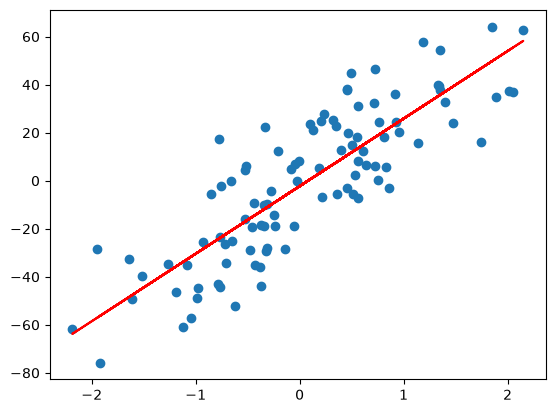

In [6]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

# now lets define our own regression class.


In [7]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.lr = learning_rate
        self.epochs = epochs
        self.m = 100
        self.b = -120

    def fit(self,X,y):
        for i in range(self.epochs):
            slope_at_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            slope_at_m = -2 * np.sum( (y - self.m * X.ravel() - self.b )* X.ravel())

            self.b = self.b - self.lr * slope_at_b
            self.m = self.m - self.lr * slope_at_m
        print(self.m,self.b,"\n")

    def predict(self,X_test):
        return (self.b + self.m * X_test)
    

In [8]:
gdr = GDRegressor(0.001,50)
gdr.fit(X_train,y_train)

28.159367347119062 -2.300457419682486 



In [9]:
y_pred = gdr.predict(X_test)

In [10]:
from sklearn.metrics import r2_score
r2_score(y_pred,y_test)

0.5196191457922587